# **Neural Network**
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues. 

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [28]:
import pandas as pd
# from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
#df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
df = pd.read_csv('Exercise7BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


How many rows and columns does the dataset contain?

In [29]:
df.shape

(17379, 17)

Are any of the columns missing values?

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target = 'cnt'
features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season','yr'
]

X = df[features].copy()
y = df[target].astype(float)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [32]:
# A super-fast baseline, just for context
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': np.float64(139.20960076354183), 'LR_MAE': 104.79577059911453, 'LR_R2': 0.3879974354720257}


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [33]:
#pip install tensorflow

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model, which is a linear stack of layers.
model = Sequential()
# Add a Dense layer with 32 units, ReLU activation, and an input dimension of 11.
model.add(Dense(32, activation='relu', input_dim=11))
# Add another Dense layer with 64 units and ReLU activation.
model.add(Dense(64, activation='relu'))
# Add a final Dense layer with 1 unit (typically used for regression tasks).
model.add(Dense(1))
# Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# and MAE metric to be used during training.
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
# Display a summary of the model architecture, including the number of parameters.
model.summary()

/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training and prediction
We split the dataset into a training and a test dataset. Then, we fit the neural network model with the training dataset and predict the values for the test dataset.

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - loss: 176.1194 - mae: 176.1194 - val_loss: 101.3252 - val_mae: 101.3252
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - loss: 101.2910 - mae: 101.2910 - val_loss: 98.7530 - val_mae: 98.7530
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 99.2610 - mae: 99.2610 - val_loss: 97.7852 - val_mae: 97.7852
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - loss: 98.1621 - mae: 98.1621 - val_loss: 96.8922 - val_mae: 96.8922
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - loss: 97.0541 - mae: 97.0541 - val_loss: 95.6688 - val_mae: 95.6688
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 95.5960 - mae: 95.5960 - val_loss: 94.2343 - val_mae: 94.2343
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - loss: 93.3633 - mae: 93.3633 - val_loss: 92.6838 - val_mae: 92.6838
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - loss: 91.6804 - mae: 91.6804 - val_loss: 91.0061 - val_mae: 91

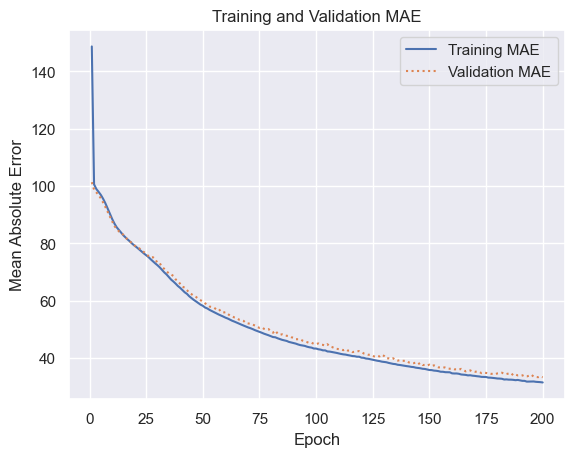

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model to the training data, specifying validation split, epochs, and batch size.
hist = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32)
# Set the style of the plots using Seaborn.
sns.set()
# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist.history['mae']
val_err = hist.history['val_mae']
# Define the number of epochs.
epochs = range(1, len(err) + 1)
# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()
# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

## Evaluate the model
You can evaluate the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), or R-squared (R2).

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the Mean Absolute Error (MAE) between the true and predicted values.
mae_nn = mean_absolute_error(y_test, y_pred)
# Calculate the Root Mean Squared Error (RMSE) between the true and predicted values.
mse_nn = mean_squared_error(y_test, y_pred)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred))
# Calculate the R-squared (R2) score, a measure of how well the model explains the variance in the data.
r2_nn = r2_score(y_test, y_pred)
# Print the calculated metrics.
print(f"Mean Absolute Error of NN: {mae_nn}")
print(f"Root Mean Squared Error of NN: {rmse_nn}")
print(f"R-squared of NN: {r2_nn}")

Mean Absolute Error of NN: 32.688697949588786
Root Mean Squared Error of NN: 52.48065026655019
R-squared of NN: 0.9130212261216075


## Compare Metrics (optional)
we compare the performance of NN with baseline linear regression.

In [37]:
import pandas as pd
results = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr},
    {'Model': 'Neural Net', 'RMSE': rmse_nn, 'MAE': mae_nn, 'R2': r2_nn},
])
results

,Model,RMSE,MAE,R2
0,Linear Regression,139.209601,104.795771,0.387997
1,Neural Net,52.480650,32.688698,0.913021


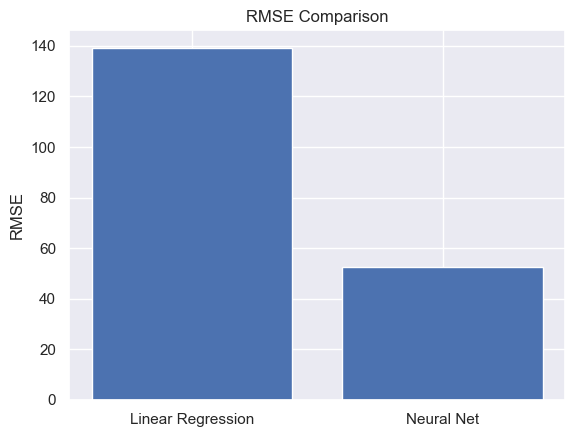

In [38]:
# Bar chart of RMSE
plt.figure()
plt.bar(results['Model'], results['RMSE'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.show()

# **Task 2: Practical NN training techniques**
The task will illustrate some useful NN training techniques, including saving and loading the trained model, using the callback function to save the best model, and adding dropout layers.



Epoch 1: val_mae improved from inf to 33.27530, saving model to weights.best.keras

Epoch 2: val_mae did not improve from 33.27530

Epoch 3: val_mae did not improve from 33.27530

Epoch 4: val_mae improved from 33.27530 to 33.02499, saving model to weights.best.keras

Epoch 5: val_mae did not improve from 33.02499

Epoch 6: val_mae improved from 33.02499 to 32.89096, saving model to weights.best.keras

Epoch 7: val_mae improved from 32.89096 to 32.83838, saving model to weights.best.keras

Epoch 8: val_mae did not improve from 32.83838

Epoch 9: val_mae did not improve from 32.83838

Epoch 10: val_mae did not improve from 32.83838

Epoch 11: val_mae improved from 32.83838 to 32.52521, saving model to weights.best.keras

Epoch 12: val_mae improved from 32.52521 to 32.35135, saving model to weights.best.keras

Epoch 13: val_mae did not improve from 32.35135

Epoch 14: val_mae improved from 32.35135 to 32.34336, saving model to weights.best.keras

Epoch 15: val_mae improved from 32.34336

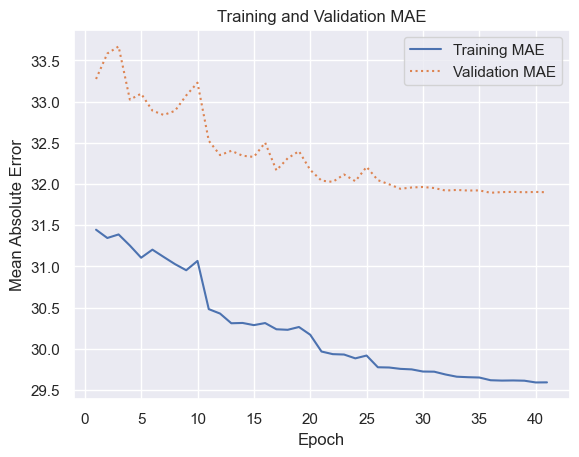

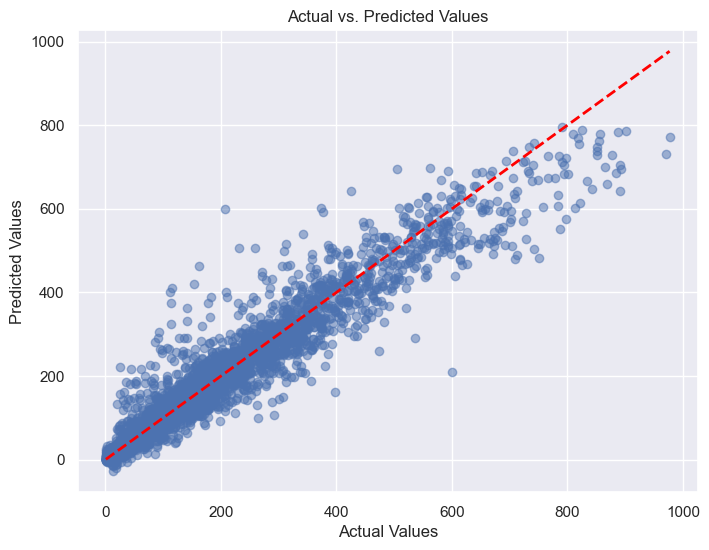

In [39]:
from json import load
import pandas as pd
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model

#-------------------------------------------------data preprocessing------------------------------------------------------------------


#-------------------------------------------------network construction-----------------------------------------------------------------

#************************************************Here you can choose to add the dropout layer or not***************************
# 
# def construct_network_model():
#   # Create a Sequential model, which is a linear stack of layers.
#   model = Sequential()
# 
#   # Add a Dense layer with 32 units, ReLU activation, and an input dimension of 4.
#   model.add(Dense(32, activation='relu', input_dim=4))
# 
#   # # Add a Dropout layer with a dropout rate of 0.5.
#   # model.add(Dropout(0.5))
# 
#   # Add another Dense layer with 64 units and ReLU activation.
#   model.add(Dense(64, activation='relu'))
# 
#   # # Add another Dropout layer with a dropout rate of 0.5.
#   # model.add(Dropout(0.5))
# 
#   # Add a final Dense layer with 1 unit (typically used for regression tasks).
#   model.add(Dense(1))
#   return model
# 
# model=construct_network_model()
# # Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# # and MAE metric to be used during training.
# model.compile(optimizer='adam', loss='mae', metrics=['mae'])
#************************************************Here you can choose to add the dropout layer or not*****************

#-------------------------------------------------model train------------------------------------------------------------------
# use the callback function to early stop, learning rate ajusting, save the best model
# Create an EarlyStopping callback to monitor the validation mean absolute error (val_mae).
# It will stop training if val_mae doesn't improve for 5 consecutive epochs and restores the best weights.
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

# Create a ReduceLROnPlateau callback to monitor val_mae.
# It reduces the learning rate by a factor of 0.5 if val_mae doesn't improve for 3 consecutive epochs.
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)

# Define the file path where the best model will be saved.
filepath = "weights.best.keras"

# Create a ModelCheckpoint callback to monitor the validation mae (val_mae).
# The callback will save thhe model's weights only if the validation mae improves.
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# Train the model using the fit method.
hist_2 = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=0)


#-------------------------------------------------model evaluation--------------------------------------------------------------------

# Set the style of the plots using Seaborn.
sns.set()

# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']

# Define the number of epochs.
epochs = range(1, len(err) + 1)

# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--------------------------------------'+'this is result of the trained model'+"---------------------------------------------")
# Print the calculated metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

#-------------------------------------------------load model and evaluation--------------------------------------------------------------------
if not filepath =="":
  # Load a pre-trained model from the specified file path.
  model = load_model(filepath)

  # Use the loaded model to predict on the test data.
  y_pred = model.predict(X_test_scaled)

  # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print('--------------------------------------'+'this is result of the model loaded from the local path'+"---------------------------------------------")

  # Print the calculated metrics.
  print(f"Mean Absolute Error: {mae}")
  print(f"Mean Squared Error: {mse}")
  print(f"R-squared: {r2}")



  # Create a scatter plot to visualize the relationship
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

  # Add labels and title
  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title("Actual vs. Predicted Values")

  # Add a diagonal line for reference (perfect predictions)
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

  # Show the plot
  plt.show()


# **Task 3: Compare the results with a linear regression model**
The task involves comparing the results obtained from the neural network with those from the linear regression model, and we should analyze the reasons behind any differences in the outcomes.

In [40]:
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set the style of the plots using seaborn.
sns.set()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('--------------------------------------'+'this is result of the neural network model'+"---------------------------------------------")
# Print the evaluation metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


# Create a Linear Regression model
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print('--------------------------------------'+'this is result of the linear regression model'+"---------------------------------------------")
print(f"Mean Absolute Error of linear model: {mae_linear}")
print(f"Root Mean Squared Error of linear model: {rmse_linear}")
print(f"R-squared of linear model: {r2_linear}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 230us/step
--------------------------------------this is result of the neural network model---------------------------------------------
Mean Absolute Error: 31.27840913069982
Root Mean Squared Error: 50.560624119293216
R-squared: 0.9192691140446588
--------------------------------------this is result of the linear regression model---------------------------------------------
Mean Absolute Error of linear model: 104.79577059911453
Root Mean Squared Error of linear model: 139.20960076354183
R-squared of linear model: 0.3879974354720257


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

## Tune the network: sizing and dropout

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model

def construct_network_model(hidden_layers=(32, 64), dropout_rate=0.0):
    """Same template as the commented-out version in Task 2, generalized so the hidden-layer
    sizes and dropout rate can be changed easily."""
    model = Sequential()
    model.add(Dense(hidden_layers[0], activation='relu', input_dim=X_train_scaled.shape[1]))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model


candidate_configs = [
    {'hidden_layers': (32, 64),        'dropout_rate': 0.0},
    {'hidden_layers': (32, 64),        'dropout_rate': 0.3},
    {'hidden_layers': (16, 32),        'dropout_rate': 0.0},
    {'hidden_layers': (64, 128),       'dropout_rate': 0.0},
    {'hidden_layers': (64, 128),       'dropout_rate': 0.3},
    {'hidden_layers': (64, 256),       'dropout_rate': 0.0},

    # Three hidden layers
    {'hidden_layers': (64, 128, 256),  'dropout_rate': 0.0},
    {'hidden_layers': (128, 256, 512),  'dropout_rate': 0.0},
]

search_results = []

for cfg in candidate_configs:
    candidate_model = construct_network_model(**cfg)

    callback = EarlyStopping(
        monitor='val_mae',
        patience=10,
        restore_best_weights=True
    )

    hist_cfg = candidate_model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=60,
        batch_size=32,
        callbacks=[callback],
        verbose=0
    )

    best_val_mae = min(hist_cfg.history['val_mae'])

    search_results.append({
        **cfg,
        'best_val_mae': best_val_mae
    })

    print(
        f"hidden_layers={cfg['hidden_layers']}, "
        f"dropout={cfg['dropout_rate']} -> "
        f"best val_mae={best_val_mae:.3f}"
    )

search_df = (
    pd.DataFrame(search_results)
    .sort_values('best_val_mae')
    .reset_index(drop=True)
)

search_df


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


hidden_layers=(32, 64), dropout=0.0 -> best val_mae=46.289


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


hidden_layers=(32, 64), dropout=0.3 -> best val_mae=69.597


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


hidden_layers=(64, 128, 256), dropout=0.0 -> best val_mae=27.309


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


hidden_layers=(128, 256, 512), dropout=0.0 -> best val_mae=26.117


,hidden_layers,dropout_rate,best_val_mae
0,"(128, 256, 512)",0.0,26.117313
1,"(64, 128, 256)",0.0,27.308830
2,"(64, 128)",0.0,35.653603
3,"(64, 256)",0.0,37.512985
4,"(32, 64)",0.0,46.288528
5,"(64, 128)",0.3,60.073410
6,"(16, 32)",0.0,63.843884
7,"(32, 64)",0.3,69.596558


### Retrain the best configuration with the full callback set

Best configuration found: {'hidden_layers': (128, 256, 512), 'dropout_rate': 0.0}


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,657 (651.00 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: val_mae improved from inf to 87.24334, saving model to weights.best_assignment.keras

Epoch 2: val_mae improved from 87.24334 to 71.70645, saving model to weights.best_assignment.keras

Epoch 3: val_mae improved from 71.70645 to 67.30579, saving model to weights.best_assignment.keras

Epoch 4: val_mae improved from 67.30579 to 60.53947, saving model to weights.best_assignment.keras

Epoch 5: val_mae improved from 60.53947 to 56.66298, saving model to weights.best_assignment.keras

Epoch 6: val_mae improved from 56.66298 to 54.67078, saving model to weights.best_assignment.keras

Epoch 7: val_mae improved from 54.67078 to 52.55181, saving model to weights.best_assignment.keras

Epoch 8: val_mae improved from 52.55181 to 50.20950, saving model to weights.best_assignment.keras

Epoch 9: val_mae improved from 50.20950 to 43.93636, saving model to weights.best_assignment.keras

Epoch 10: val_mae improved from 43.93636 to 40.28170, saving model to weights.best_assignment.keras

Epo

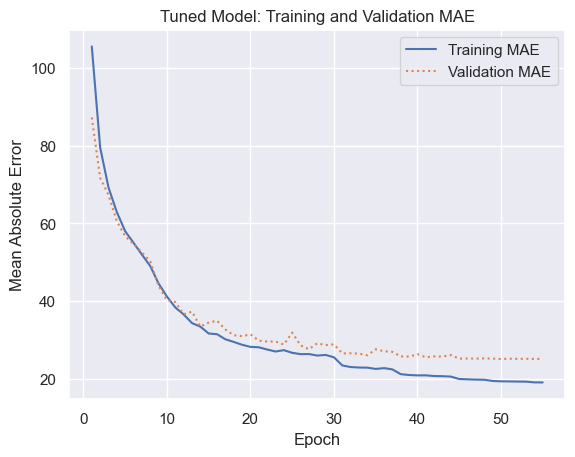

In [42]:
best_cfg = {
    'hidden_layers': tuple(search_df.iloc[0]['hidden_layers']),
    'dropout_rate': float(search_df.iloc[0]['dropout_rate']),
}
print("Best configuration found:", best_cfg)

model = construct_network_model(**best_cfg)
model.summary()

# Same callback recipe as Task 2: early stopping, LR reduction on plateau, checkpoint the best weights.
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)
filepath = "weights.best_assignment.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

hist_2 = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)

sns.set()
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']
epochs = range(1, len(err) + 1)
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Tuned Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.show()


### Evaluate the tuned model and compare against the baselines

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step
--------------------------------------this is the result of the tuned NN, WITHOUT interaction features---------------------------------------------
Mean Absolute Error: 24.210609868023077
Root Mean Squared Error: 40.59493312075466
R-squared: 0.9479574549792366


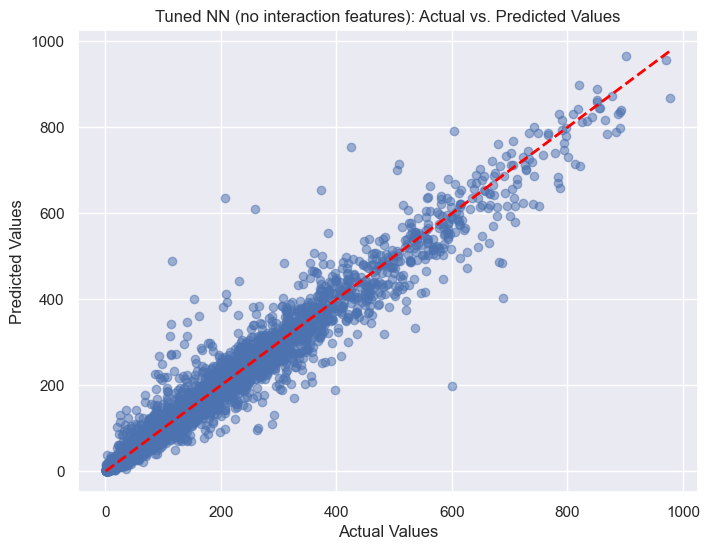

In [43]:
model = load_model(filepath)
y_pred_no_int = model.predict(X_test_scaled)

mae_no_int = mean_absolute_error(y_test, y_pred_no_int)
rmse_no_int = np.sqrt(mean_squared_error(y_test, y_pred_no_int))
r2_no_int = r2_score(y_test, y_pred_no_int)

print('--------------------------------------' + 'this is the result of the tuned NN, WITHOUT interaction features' + "---------------------------------------------")
print(f"Mean Absolute Error: {mae_no_int}")
print(f"Root Mean Squared Error: {rmse_no_int}")
print(f"R-squared: {r2_no_int}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_no_int, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Tuned NN (no interaction features): Actual vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red', lw=2)
plt.show()


## Add interaction features and compare

Features without interactions: ['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'hr', 'weekday', 'workingday', 'holiday', 'season', 'yr']
Features with interactions:    ['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'hr', 'weekday', 'workingday', 'holiday', 'season', 'yr', 'hr_workingday', 'weathersit_hum']


/opt/anaconda3/envs/sdb/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_mae improved from inf to 88.83713, saving model to weights.best_assignment_interactions.keras

Epoch 2: val_mae improved from 88.83713 to 73.84528, saving model to weights.best_assignment_interactions.keras

Epoch 3: val_mae improved from 73.84528 to 66.38373, saving model to weights.best_assignment_interactions.keras

Epoch 4: val_mae improved from 66.38373 to 61.41112, saving model to weights.best_assignment_interactions.keras

Epoch 5: val_mae improved from 61.41112 to 57.72202, saving model to weights.best_assignment_interactions.keras

Epoch 6: val_mae improved from 57.72202 to 50.72764, saving model to weights.best_assignment_interactions.keras

Epoch 7: val_mae improved from 50.72764 to 44.65204, saving model to weights.best_assignment_interactions.keras

Epoch 8: val_mae improved from 44.65204 to 42.14629, saving model to weights.best_assignment_interactions.keras

Epoch 9: val_mae improved from 42.14629 to 38.32856, saving model to weights.best_assignment_interac

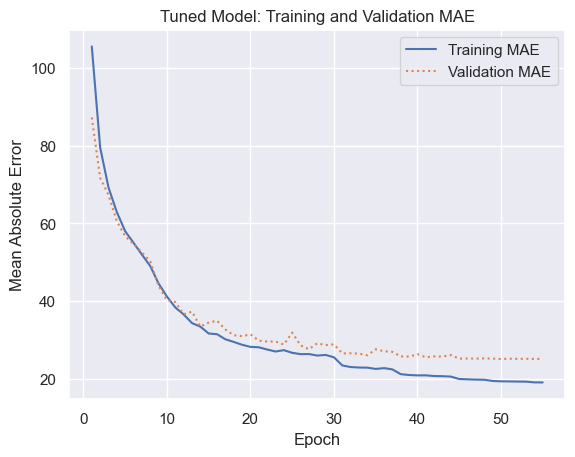

In [ ]:
# Build the same 11 features plus two interaction terms.
df_fe = df.copy()
df_fe['hr_workingday'] = df_fe['hr'] * df_fe['workingday']
df_fe['weathersit_hum'] = df_fe['weathersit'] * df_fe['hum']

features_fe = features + ['hr_workingday', 'weathersit_hum']
X_fe = df_fe[features_fe].copy()
y_fe = df_fe[target].astype(float)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Features without interactions:", features)
print("Features with interactions:   ", features_fe)

model_int = Sequential()
model_int.add(Dense(best_cfg['hidden_layers'][0], activation='relu', input_dim=X_train_fe_scaled.shape[1]))
if best_cfg['dropout_rate'] > 0:
    model_int.add(Dropout(best_cfg['dropout_rate']))
for units in best_cfg['hidden_layers'][1:]:
    model_int.add(Dense(units, activation='relu'))
    if best_cfg['dropout_rate'] > 0:
        model_int.add(Dropout(best_cfg['dropout_rate']))
model_int.add(Dense(1))
model_int.compile(optimizer='adam', loss='mae', metrics=['mae'])

early_stop_int = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
reduce_lr_int = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)
filepath_int = "weights.best_assignment_interactions.keras"
checkpoint_int = ModelCheckpoint(filepath_int, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

hist_int = model_int.fit(
    X_train_fe_scaled, y_train_fe,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_int, reduce_lr_int, checkpoint_int],
    verbose=0
)

model_int = load_model(filepath_int)
y_pred_int = model_int.predict(X_test_fe_scaled)

mae_int = mean_absolute_error(y_test_fe, y_pred_int)
rmse_int = np.sqrt(mean_squared_error(y_test_fe, y_pred_int))
r2_int = r2_score(y_test_fe, y_pred_int)

print('--------------------------------------' + 'this is the result of the tuned NN, WITH interaction features' + "---------------------------------------------")
print(f"Mean Absolute Error: {mae_int}")
print(f"Root Mean Squared Error: {rmse_int}")
print(f"R-squared: {r2_int}")

sns.set()
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']
epochs = range(1, len(err) + 1)
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Tuned Model: Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.show()


### Compare: with vs. without interaction features

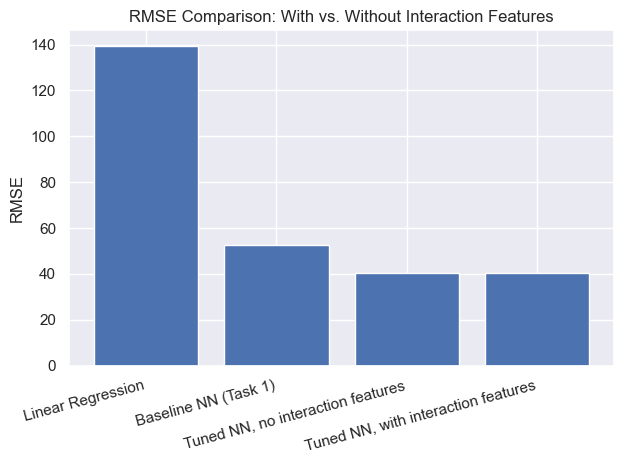

In [45]:
comparison_results = pd.DataFrame([
    {'Model': 'Linear Regression',                  'RMSE': rmse_lr,     'MAE': mae_lr,     'R2': r2_lr},
    {'Model': 'Baseline NN (Task 1)',                'RMSE': rmse_nn,     'MAE': mae_nn,     'R2': r2_nn},
    {'Model': 'Tuned NN, no interaction features',   'RMSE': rmse_no_int, 'MAE': mae_no_int, 'R2': r2_no_int},
    {'Model': 'Tuned NN, with interaction features', 'RMSE': rmse_int,    'MAE': mae_int,    'R2': r2_int},
])
comparison_results

plt.figure()
plt.bar(comparison_results['Model'], comparison_results['RMSE'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison: With vs. Without Interaction Features')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [46]:
comparison_results

,Model,RMSE,MAE,R2
0,Linear Regression,139.209601,104.795771,0.387997
1,Baseline NN (Task 1),52.480650,32.688698,0.913021
2,"Tuned NN, no interaction features",40.594933,24.210610,0.947957
3,"Tuned NN, with interaction features",40.311386,24.250377,0.948682
